In [1]:
import pandas as pd
import os
import numpy as np
import os
pd.options.display.float_format = '{:.2f}'.format
current_directory = os.getcwd()
print(current_directory)

d:\JAMALI FORECASTING\1_pre


In [2]:
pathload=os.path.join(current_directory, 'A_data_df3.xlsx')
df_awal=pd.read_excel(pathload)
df_awal

,Date,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Tanggal_sin,Tanggal_cos,Bulan_sin,Bulan_cos,...,Malang,Pasuruan,Pekalongan,Semarang,Sidoarjo,Surabaya,Surakarta,Tangerang,Tegal,Yogyakarta
0,2022-01-01 00:30:00,18402.00,0.13,0.99,-0.97,-0.22,0.00,1.00,0.00,1.00,...,21.70,23.90,24.70,24.80,24.50,24.80,22.80,25.15,25.15,22.70
1,2022-01-01 01:00:00,18214.00,0.26,0.97,-0.97,-0.22,0.00,1.00,0.00,1.00,...,22.10,23.70,24.70,25.70,24.40,24.50,22.60,25.00,25.10,22.50
2,2022-01-01 01:30:00,17974.00,0.38,0.92,-0.97,-0.22,0.00,1.00,0.00,1.00,...,21.95,23.55,24.65,25.05,24.15,24.20,22.60,24.90,25.00,22.45
3,2022-01-01 02:00:00,17729.00,0.50,0.87,-0.97,-0.22,0.00,1.00,0.00,1.00,...,21.80,23.40,24.60,24.40,23.90,23.90,22.60,24.80,24.90,22.40
4,2022-01-01 02:30:00,17532.00,0.61,0.79,-0.97,-0.22,0.00,1.00,0.00,1.00,...,21.40,23.40,24.15,24.10,23.95,24.00,22.60,24.80,24.65,22.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67123,2025-10-30 10:00:00,30957.80,0.50,-0.87,0.43,-0.90,-0.21,0.98,-1.00,-0.00,...,25.30,29.80,30.70,29.60,29.70,29.00,28.90,29.90,31.10,27.10
67124,2025-10-30 10:30:00,30580.79,0.38,-0.92,0.43,-0.90,-0.21,0.98,-1.00,-0.00,...,25.25,30.30,31.15,29.70,30.25,29.45,29.10,30.60,31.65,27.20
67125,2025-10-30 11:00:00,31497.36,0.26,-0.97,0.43,-0.90,-0.21,0.98,-1.00,-0.00,...,25.20,30.80,31.60,29.80,30.80,29.90,29.30,31.30,32.20,27.30
67126,2025-10-30 11:30:00,31337.59,0.13,-0.99,0.43,-0.90,-0.21,0.98,-1.00,-0.00,...,25.25,30.95,31.75,29.95,31.25,30.10,29.45,31.75,32.65,27.35


In [3]:
df_awal.columns

Index(['Date', 'Beban', 'Jam_sin', 'Jam_cos', 'Hari_sin', 'Hari_cos',
       'Tanggal_sin', 'Tanggal_cos', 'Bulan_sin', 'Bulan_cos',
       'Holiday_Impact', 'Bandung', 'Bekasi', 'Bogor', 'Cikarang', 'Cirebon',
       'Denpasar', 'Gresik', 'Jakarta', 'Jember', 'Karawang', 'Malang',
       'Pasuruan', 'Pekalongan', 'Semarang', 'Sidoarjo', 'Surabaya',
       'Surakarta', 'Tangerang', 'Tegal', 'Yogyakarta'],
      dtype='object')

# PCA hanya SUHU Kota

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
def PCA_suhu_manual(df):
    # 1. Pilih hanya kolom cuaca
    cols_suhu = ['Bandung', 'Bekasi', 'Bogor', 'Cikarang', 'Cirebon',
       'Denpasar', 'Gresik', 'Jakarta', 'Jember', 'Karawang', 'Malang',
       'Pasuruan', 'Pekalongan', 'Semarang', 'Sidoarjo', 'Surabaya',
       'Surakarta', 'Tangerang', 'Tegal', 'Yogyakarta']
    X = df[cols_suhu]
    mean        = np.mean(X, axis=0)
    std_dev     = np.std(X, axis=0)
    X_scaled    = (X - mean) / std_dev
    X_scaled    = np.where(np.isnan(X_scaled), 0, X_scaled)
    X_scaled    =pd.DataFrame(X_scaled, columns=X.columns)
    # 2. Standarisasi (WAJIB untuk PCA)
    covariance_matrix = np.cov(X_scaled, rowvar=False)
    eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

    # sorting nilai eigen values dan eigen values dari tinggi ke rendah
    tinggi_ke_rendah = np.argsort(eigen_values)[::-1]
    eigen_values = eigen_values[tinggi_ke_rendah]
    eigen_vectors = eigen_vectors[ : , tinggi_ke_rendah]

    #explained_variances dari principal component
    explained_variances =np.array(eigen_values / np.sum(eigen_values) * 100)

    sumbu_y=np.cumsum(explained_variances)
    sumbu_x = np.arange(1, len(sumbu_y)+1)
    plt.figure(figsize=(15,6))
    plt.step(y=sumbu_y, x=sumbu_x, where='mid')
    plt.bar(height=explained_variances, x=sumbu_x,color='red')
    plt.xlabel("Index principal komponen (%)",fontsize=12)
    plt.ylabel("Explained variance (%)",fontsize=12)
    plt.yticks(np.arange(0, 110, 10))
    plt.xticks(sumbu_x)
    for i, (x, y) in enumerate(zip(sumbu_x, explained_variances)):
        plt.text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=12)
    plt.grid()
    plt.legend(["Kumulatif explained variances (%)", "Individu explained variances (%)"],loc='upper right',bbox_to_anchor=(1, 0.6))
    plt.show()
    jumlah_komponen=1
    X_pca=np.matmul(X_scaled, eigen_vectors[:, :jumlah_komponen])
    return X_pca

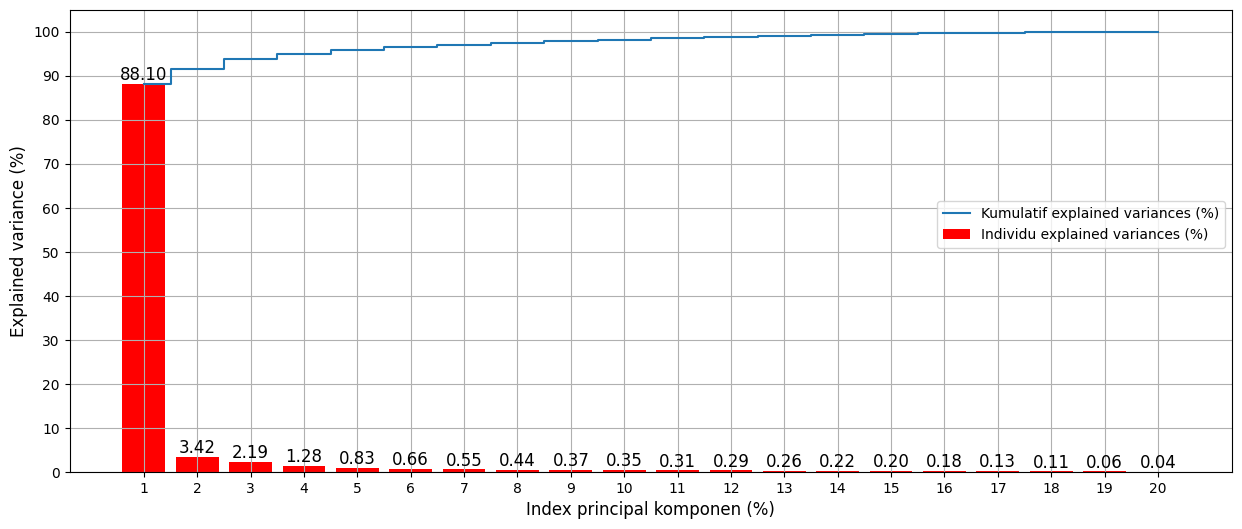

,0
0,-4.40
1,-4.57
2,-4.81
3,-5.06
4,-5.22
...,...
67123,3.77
67124,4.43
67125,5.09
67126,5.52


In [5]:
df_pca_suhu_manual = PCA_suhu_manual(df_awal.copy())
df_pca_suhu_manual = df_pca_suhu_manual.copy()
df_pca_suhu_manual

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
def PCA_suhu(df):
    # 1. Pilih hanya kolom cuaca
    cols_suhu = ['Bandung', 'Bekasi', 'Bogor', 'Cikarang', 'Cirebon',
       'Denpasar', 'Gresik', 'Jakarta', 'Jember', 'Karawang', 'Malang',
       'Pasuruan', 'Pekalongan', 'Semarang', 'Sidoarjo', 'Surabaya',
       'Surakarta', 'Tangerang', 'Tegal', 'Yogyakarta']
    df_suhu = df[cols_suhu]

    # 2. Standarisasi (WAJIB untuk PCA)
    # PCA sangat sensitif terhadap skala, jadi harus di-scale dulu
    scaler = StandardScaler()
    suhu_scaled = scaler.fit_transform(df_suhu)

    # 3. Terapkan PCA
    # n_components=1 bertujuan untuk mereduksi ke 1 dimensi
    pca = PCA(n_components=1)
    suhu_pca = pca.fit_transform(suhu_scaled)

    # 4. Masukkan kembali ke DataFrame utama
    df['Suhu_PCA'] = suhu_pca

    # 5. Hapus kolom suhu kota asli (agar tidak duplikat informasi)
    df_final = df.drop(columns=cols_suhu)

    # Sekarang df_final siap digabung dengan Jam_sin, Holiday_Impact, dll.
    print(f"PCA Component 1 menangkap {pca.explained_variance_ratio_[0]:.2%} informasi suhu.")
    return df_final

In [7]:
df_2 = PCA_suhu(df_awal.copy())
df_2 = df_2.copy()
df_2

PCA Component 1 menangkap 88.10% informasi suhu.


,Date,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Tanggal_sin,Tanggal_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
0,2022-01-01 00:30:00,18402.00,0.13,0.99,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76,-4.40
1,2022-01-01 01:00:00,18214.00,0.26,0.97,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76,-4.57
2,2022-01-01 01:30:00,17974.00,0.38,0.92,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76,-4.81
3,2022-01-01 02:00:00,17729.00,0.50,0.87,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76,-5.06
4,2022-01-01 02:30:00,17532.00,0.61,0.79,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76,-5.22
...,...,...,...,...,...,...,...,...,...,...,...,...
67123,2025-10-30 10:00:00,30957.80,0.50,-0.87,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01,3.77
67124,2025-10-30 10:30:00,30580.79,0.38,-0.92,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01,4.43
67125,2025-10-30 11:00:00,31497.36,0.26,-0.97,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01,5.09
67126,2025-10-30 11:30:00,31337.59,0.13,-0.99,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01,5.52


In [8]:
df_3 = df_2.drop(columns=['Tanggal_sin', 'Tanggal_cos']).copy()
df_3.set_index('Date', inplace=True)
df_3.index = pd.to_datetime(df_3.index)
df_3= df_3.astype('float32').copy()

In [9]:
df_3.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00
mean,25439.13,0.00,-0.00,0.00,0.00,0.03,-0.03,1.00,0.00
std,3161.22,0.71,0.71,0.71,0.71,0.71,0.71,0.05,4.20
min,13475.00,-1.00,-1.00,-0.97,-0.90,-1.00,-1.00,0.70,-10.78
25%,23153.00,-0.71,-0.71,-0.78,-0.90,-0.50,-0.87,1.01,-3.36
50%,25444.64,0.00,-0.00,0.00,-0.22,0.00,-0.00,1.01,-0.88
75%,27759.07,0.71,0.71,0.78,0.62,0.87,0.50,1.01,3.21
max,34104.89,1.00,1.00,0.97,1.00,1.00,1.00,1.01,13.80


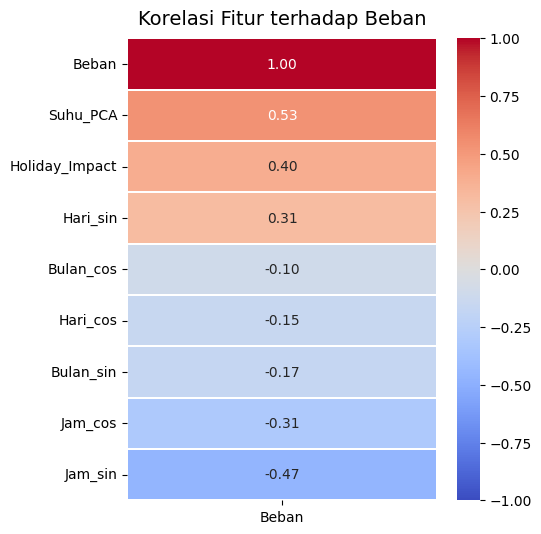

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung korelasi
correlation = df_3.corr()

# --- OPSI 1: Heatmap Fokus ke 'Beban' (Paling Direkomendasikan) ---
plt.figure(figsize=(5, 6)) # Ukuran ramping memanjang ke bawah

# Kita ambil hanya kolom 'Beban', lalu urutkan dari terbesar
target_corr = correlation[['Beban']].sort_values(by='Beban', ascending=False)

# Plot Heatmap
sns.heatmap(target_corr, 
            annot=True,    # Tampilkan angkanya
            cmap='coolwarm', # Warna: Merah (Positif), Biru (Negatif)
            vmin=-1, vmax=1, # Batas warna dari -1 hingga 1
            fmt='.2f',     # Format 2 angka di belakang koma
            linewidths=0.2)

plt.title("Korelasi Fitur terhadap Beban", fontsize=14, pad=10)
plt.show()

In [11]:
def scale_array(arr, new_min=-1, new_max=1):

    orig_min = np.min(arr)
    orig_max = np.max(arr)
    scaled_arr = (arr - orig_min) / (orig_max - orig_min) * (new_max - new_min) + new_min
    return scaled_arr, orig_min, orig_max

def inverse_scale_array(scaled_arr, orig_min, orig_max, new_min=-1, new_max=1):

    original_arr = (scaled_arr - new_min) / (new_max - new_min) * (orig_max - orig_min) + orig_min
    return original_arr


# training testing split

In [12]:
df_3

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
Date,,,,,,,,,
2022-01-01 00:30:00,18402.00,0.13,0.99,-0.97,-0.22,0.00,1.00,0.76,-4.40
2022-01-01 01:00:00,18214.00,0.26,0.97,-0.97,-0.22,0.00,1.00,0.76,-4.57
2022-01-01 01:30:00,17974.00,0.38,0.92,-0.97,-0.22,0.00,1.00,0.76,-4.81
2022-01-01 02:00:00,17729.00,0.50,0.87,-0.97,-0.22,0.00,1.00,0.76,-5.06
2022-01-01 02:30:00,17532.00,0.61,0.79,-0.97,-0.22,0.00,1.00,0.76,-5.22
...,...,...,...,...,...,...,...,...,...
2025-10-30 10:00:00,30957.80,0.50,-0.87,0.43,-0.90,-1.00,-0.00,1.01,3.77
2025-10-30 10:30:00,30580.79,0.38,-0.92,0.43,-0.90,-1.00,-0.00,1.01,4.43
2025-10-30 11:00:00,31497.36,0.26,-0.97,0.43,-0.90,-1.00,-0.00,1.01,5.09


In [13]:
# Select data from the beginning up to (and including) October 30, 2024
train_data = df_3.loc[:'2024-10-31 00:00:00'].copy()

# Select the remaining data (from 2024-10-31 onwards) for testing
test_data = df_3.loc['2024-10-31 00:30:00':].copy()

# Check the size to be sure
print(f"Training Data: {train_data.shape} (Ends at: {train_data.index.max()})")
print(f"Testing Data : {test_data.shape} (Starts at: {test_data.index.min()})")

Training Data: (49632, 9) (Ends at: 2024-10-31 00:00:00)
Testing Data : (17496, 9) (Starts at: 2024-10-31 00:30:00)


In [14]:
train_data

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
Date,,,,,,,,,
2022-01-01 00:30:00,18402.00,0.13,0.99,-0.97,-0.22,0.00,1.00,0.76,-4.40
2022-01-01 01:00:00,18214.00,0.26,0.97,-0.97,-0.22,0.00,1.00,0.76,-4.57
2022-01-01 01:30:00,17974.00,0.38,0.92,-0.97,-0.22,0.00,1.00,0.76,-4.81
2022-01-01 02:00:00,17729.00,0.50,0.87,-0.97,-0.22,0.00,1.00,0.76,-5.06
2022-01-01 02:30:00,17532.00,0.61,0.79,-0.97,-0.22,0.00,1.00,0.76,-5.22
...,...,...,...,...,...,...,...,...,...
2024-10-30 22:00:00,29019.07,-0.50,0.87,0.97,-0.22,-1.00,-0.00,1.01,0.45
2024-10-30 22:30:00,28465.74,-0.38,0.92,0.97,-0.22,-1.00,-0.00,1.01,0.13
2024-10-30 23:00:00,27755.75,-0.26,0.97,0.97,-0.22,-1.00,-0.00,1.01,-0.18


In [15]:
train_data.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,49632.00,49632.00,49632.00,49632.00,49632.00,49632.00,49632.00,49632.00,49632.00
mean,24933.85,0.00,0.00,0.00,0.00,0.04,-0.04,1.00,-0.30
std,3040.18,0.71,0.71,0.71,0.71,0.71,0.71,0.05,4.28
min,13475.00,-1.00,-1.00,-0.97,-0.90,-1.00,-1.00,0.70,-10.78
25%,22701.94,-0.71,-0.71,-0.78,-0.90,-0.50,-0.87,1.01,-3.77
50%,24934.72,0.00,-0.00,0.00,-0.22,0.00,-0.00,1.01,-1.27
75%,27240.23,0.71,0.71,0.78,0.62,0.87,0.50,1.01,2.89
max,32758.62,1.00,1.00,0.97,1.00,1.00,1.00,1.01,13.80


In [80]:
test_data

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
Date,,,,,,,,,
2024-10-31 00:30:00,26460.92,0.13,0.99,0.43,-0.90,-1.00,-0.00,1.01,-0.83
2024-10-31 01:00:00,26184.93,0.26,0.97,0.43,-0.90,-1.00,-0.00,1.01,-1.03
2024-10-31 01:30:00,25976.69,0.38,0.92,0.43,-0.90,-1.00,-0.00,1.01,-1.28
2024-10-31 02:00:00,25745.22,0.50,0.87,0.43,-0.90,-1.00,-0.00,1.01,-1.54
2024-10-31 02:30:00,25441.97,0.61,0.79,0.43,-0.90,-1.00,-0.00,1.01,-1.72
...,...,...,...,...,...,...,...,...,...
2025-10-30 10:00:00,30957.80,0.50,-0.87,0.43,-0.90,-1.00,-0.00,1.01,3.77
2025-10-30 10:30:00,30580.79,0.38,-0.92,0.43,-0.90,-1.00,-0.00,1.01,4.43
2025-10-30 11:00:00,31497.36,0.26,-0.97,0.43,-0.90,-1.00,-0.00,1.01,5.09


In [85]:
train_data.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,49632.00,49632.00,49632.00,49632.00,49632.00,49632.00,49632.00,49632.00,49632.00
mean,24933.85,0.00,0.00,0.00,0.00,0.04,-0.04,1.00,-0.30
std,3040.18,0.71,0.71,0.71,0.71,0.71,0.71,0.05,4.28
min,13475.00,-1.00,-1.00,-0.97,-0.90,-1.00,-1.00,0.70,-10.78
25%,22701.94,-0.71,-0.71,-0.78,-0.90,-0.50,-0.87,1.01,-3.77
50%,24934.72,0.00,-0.00,0.00,-0.22,0.00,-0.00,1.01,-1.27
75%,27240.23,0.71,0.71,0.78,0.62,0.87,0.50,1.01,2.89
max,32758.62,1.00,1.00,0.97,1.00,1.00,1.00,1.01,13.80


In [ ]:
#train_data.to_excel('B_train_data.xlsx')
#test_data.to_excel('B_test_data.xlsx')

# df4

In [81]:
df_4 = df_3.astype('float32').copy()
df_4['Suhu_PCA'], min_suhu, max_suhu = scale_array(df_4['Suhu_PCA'].values, new_min=-1, new_max=1)
df_4['Holiday_Impact'], min_holiday, max_holiday = scale_array(
    df_4['Holiday_Impact'].values, 
    new_min=-1, 
    new_max=1
)



scaled_beban, min_beban, max_beban = scale_array(df_4['Beban'].values, new_min=0, new_max=1)

# Update kolom di DataFrame
df_4['Beban'] = scaled_beban
df_4

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
Date,,,,,,,,,
2022-01-01 00:30:00,0.24,0.13,0.99,-0.97,-0.22,0.00,1.00,-0.59,-0.48
2022-01-01 01:00:00,0.23,0.26,0.97,-0.97,-0.22,0.00,1.00,-0.59,-0.49
2022-01-01 01:30:00,0.22,0.38,0.92,-0.97,-0.22,0.00,1.00,-0.59,-0.51
2022-01-01 02:00:00,0.21,0.50,0.87,-0.97,-0.22,0.00,1.00,-0.59,-0.53
2022-01-01 02:30:00,0.20,0.61,0.79,-0.97,-0.22,0.00,1.00,-0.59,-0.55
...,...,...,...,...,...,...,...,...,...
2025-10-30 10:00:00,0.85,0.50,-0.87,0.43,-0.90,-1.00,-0.00,1.00,0.18
2025-10-30 10:30:00,0.83,0.38,-0.92,0.43,-0.90,-1.00,-0.00,1.00,0.24
2025-10-30 11:00:00,0.87,0.26,-0.97,0.43,-0.90,-1.00,-0.00,1.00,0.29


In [82]:
df_4.min(), df_4.max()

(Beban             0.00
 Jam_sin          -1.00
 Jam_cos          -1.00
 Hari_sin         -0.97
 Hari_cos         -0.90
 Bulan_sin        -1.00
 Bulan_cos        -1.00
 Holiday_Impact   -1.00
 Suhu_PCA         -1.00
 dtype: float32,
 Beban            1.00
 Jam_sin          1.00
 Jam_cos          1.00
 Hari_sin         0.97
 Hari_cos         1.00
 Bulan_sin        1.00
 Bulan_cos        1.00
 Holiday_Impact   1.00
 Suhu_PCA         1.00
 dtype: float32)

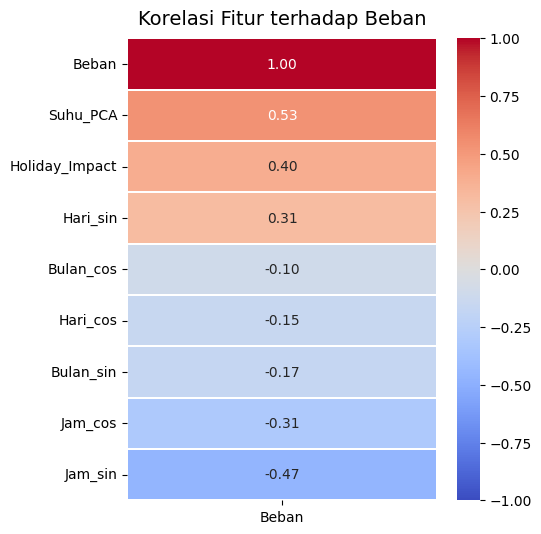

In [83]:

# Hitung korelasi
correlation = df_4.corr()

# --- OPSI 1: Heatmap Fokus ke 'Beban' (Paling Direkomendasikan) ---
plt.figure(figsize=(5, 6)) # Ukuran ramping memanjang ke bawah

# Kita ambil hanya kolom 'Beban', lalu urutkan dari terbesar
target_corr = correlation[['Beban']].sort_values(by='Beban', ascending=False)

# Plot Heatmap
sns.heatmap(target_corr, 
            annot=True,    # Tampilkan angkanya
            cmap='coolwarm', # Warna: Merah (Positif), Biru (Negatif)
            vmin=-1, vmax=1, # Batas warna dari -1 hingga 1
            fmt='.2f',     # Format 2 angka di belakang koma
            linewidths=0.2)

plt.title("Korelasi Fitur terhadap Beban", fontsize=14, pad=10)
plt.show()